<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/3_visualizacion_analisis_exploratorio/3_visualizaci%C3%B3n_analisis_exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 3: Análisis Exploratorio, Pandas Avanzado y Visualización de Datos

---
## 1. Importación de Librerías y Carga de Datos
Como siempre, el primer paso es preparar nuestro entorno de trabajo.

In [2]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
california = fetch_california_housing(as_frame=True)
df = california.frame

# Mostramos las primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 📊 Diccionario de Datos: California Housing Dataset

Antes de manipular cualquier dataset, el paso cero de todo Científico de Datos es entender qué significa cada columna. Es importante notar que **este conjunto de datos contiene estadísticas agregadas a nivel de "distrito" o "bloque"**, no información de casas individuales.

**Características Predictoras (Variables Independientes / Features):**
* **`MedInc`**: Ingreso medio de los hogares en el distrito (expresado en decenas de miles de dólares, ej. 3.5 = $35,000).
* **`HouseAge`**: Edad mediana de las construcciones en el distrito (en años).
* **`AveRooms`**: Promedio de habitaciones totales por hogar.
* **`AveBedrms`**: Promedio de dormitorios por hogar.
* **`Population`**: Población total que reside en el distrito.
* **`AveOccup`**: Ocupación promedio (número de personas promedio por hogar).
* **`Latitude`**: Latitud geográfica del distrito.
* **`Longitude`**: Longitud geográfica del distrito.

**Nuestra Variable Objetivo (Variable Dependiente / Target):**
* 🎯 **`MedHouseVal`**: Valor medio de las viviendas en el distrito (expresado en cientos de miles de dólares, ej. 2.5 = $250,000). *Esta es la variable que intentaremos predecir en nuestra próxima clase de Modelos de Regresión.*

### 🧑‍💻 Ejercicio Práctico 1: Exploración Inicial
Antes de transformar los datos, necesitamos conocerlos.

**Tu tarea:**
1. Muestra la información general del DataFrame para verificar los tipos de datos.
2. Genera un resumen estadístico de las variables numéricas.
3. Comprueba si existen valores nulos (`NaN`) en el dataset.

In [3]:
# 1. Muestra la información general del dataset
# [TU CÓDIGO AQUÍ]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# 2. Genera un resumen estadístico de todas las variables
# [TU CÓDIGO AQUÍ]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# 3. Comprueba si hay valores nulos
# [TU CÓDIGO AQUÍ]
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


---
## Análisis Univariado (Perspectiva Visual)

El objetivo es entender la **distribución individual** de nuestras variables más importantes. El Análisis Univariado nos ayuda a responder preguntas como:

- *¿Los datos siguen una distribución normal?*
- *¿Están sesgados?*
- *¿Hay valores atípicos (outliers) extremos?*

Vamos a comenzar analizando nuestra **variable objetivo** (la que queremos predecir): el valor medio de la vivienda (`MedHouseVal`). Para esto, la mejor herramienta es un **Histograma con estimación de densidad de kernel (KDE)**.

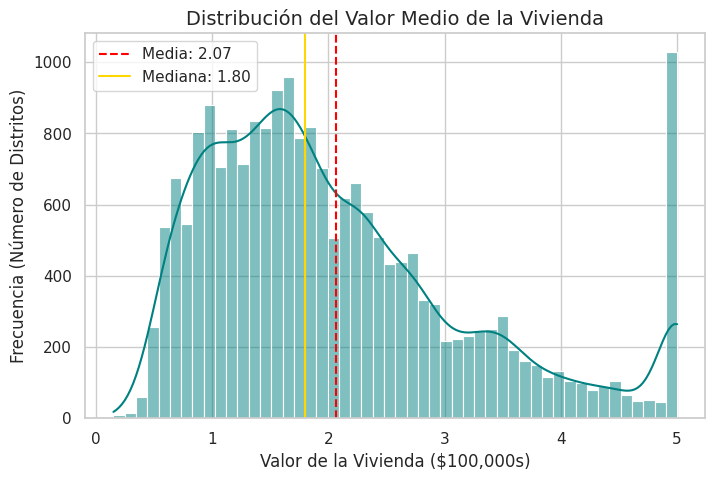

In [4]:
# Demostración: Distribución de la variable objetivo
plt.figure(figsize=(8, 5))

# Usamos seaborn para crear un histograma con la curva de densidad (KDE)
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='teal')

# Añadimos líneas para marcar la media y la mediana
plt.axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Media: {df['MedHouseVal'].mean():.2f}")
plt.axvline(df['MedHouseVal'].median(), color='gold', linestyle='-', label=f"Mediana: {df['MedHouseVal'].median():.2f}")

plt.title('Distribución del Valor Medio de la Vivienda', fontsize=14)
plt.xlabel('Valor de la Vivienda ($100,000s)')
plt.ylabel('Frecuencia (Número de Distritos)')
plt.legend()
plt.show()

**🔍 Análisis rápido del gráfico anterior:**

Fíjate en dos cosas cruciales:
1. La distribución está **sesgada a la derecha** (la "cola" es más larga hacia los valores altos). Esto es típico en variables financieras.
2. ¡Hay un pico anormal justo en el valor 5.0 ($500,000)! Esto indica que los datos fueron "topados" (casteados); cualquier casa que valiera más de medio millón se registró simplemente como 5.0. *¡Esto es oro puro para nuestro futuro modelo de regresión, ya que podríamos necesitar tratar esos topes!*

### 🧑‍💻 Ejercicio Práctico: Automatizando el Análisis Univariado

Hacer un gráfico por celda está bien para las variables más importantes, pero en datasets reales con decenas de columnas, necesitamos ser más eficientes.

Vamos a visualizar la distribución de **todas** las variables restantes (`HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`).

**Tu tarea:**
1. Genera histogramas para el resto de las variables numéricas del dataset.
*💡 Pista Pro: No tienes que hacer un `for loop` complejo. El propio Pandas tiene un método mágico llamado `df.hist()` que grafica todas las columnas numéricas de un DataFrame a la vez. Solo necesitas pasarle parámetros como `bins` y `figsize`.*
2. Observa detenidamente las gráficas generadas, especialmente los ejes X. Busca anomalías.

In [ ]:
# Genera los histogramas masivos para todo el DataFrame
# Pista: usa df.hist(bins=..., figsize=(... , ...))
# [TU CÓDIGO AQUÍ]




# Esta línea ayuda a que los títulos de los subgráficos no se superpongan
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

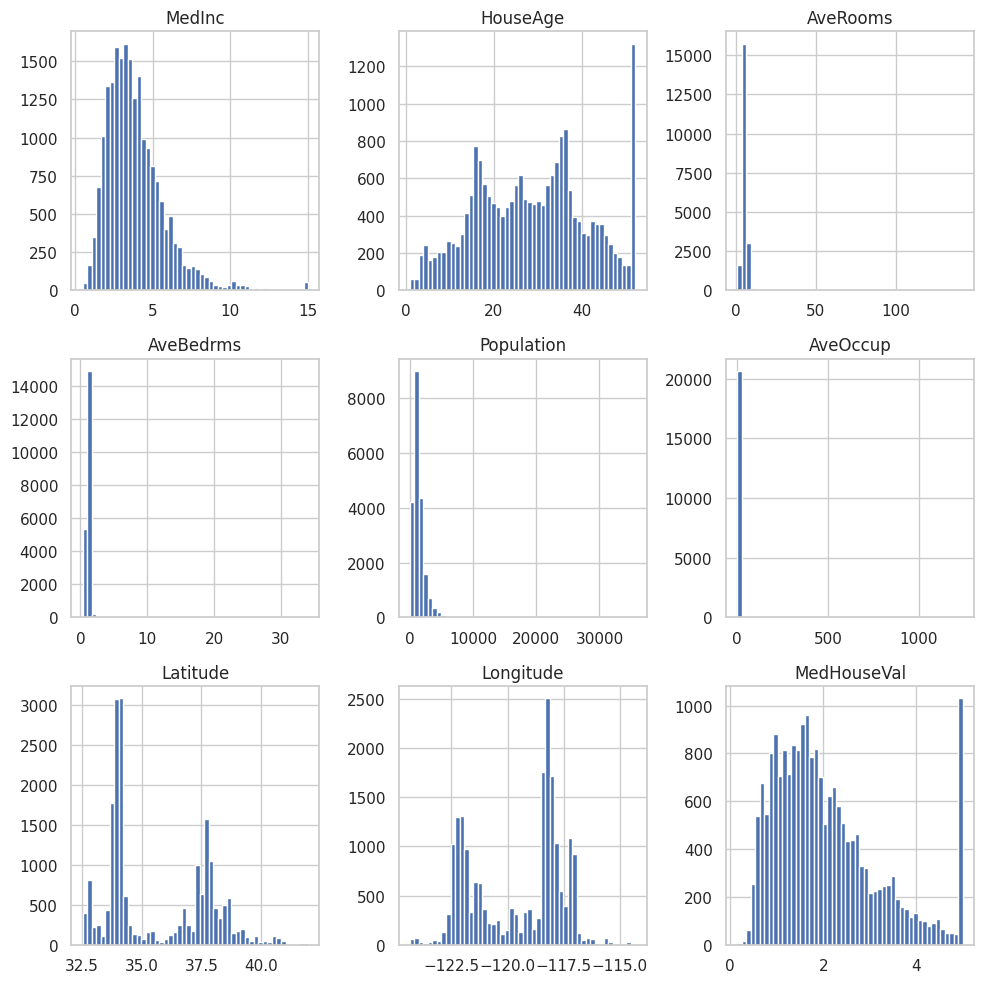

In [ ]:
df.hist(bins=50, figsize=(10, 10))
plt.tight_layout()
plt.show()

### Análisis detallado

Ya obtuvimos una perspectiva general de la distribución de todas las variables. Ahora es posible hacer un análisis más detallado de ciertas variables de interes ejemplo: AveRooms y AveBedrms. Las cuales muestran una distribución muy particular. Ahora genera histogramas detallados para estas dos variables.

In [ ]:
# Genera los histogramas para AveRooms y AveBedrms
# [TU CÓDIGO AQUÍ]


**✍️ Tu Análisis General (Responde aquí):**

Observa con atención los histogramas que acabas de generar y responde:

1. El gráfico de `HouseAge` (Edad de la casa) se ve bastante normal, pero mira los gráficos de `AveRooms` (Habitaciones promedio), `AveBedrms` y `AveOccup` (Ocupación). ¿Notas algo extraño en la forma de sus barras y en la escala de su eje X? ¿Qué crees que está causando que el gráfico se vea casi vacío o "aplastado"?
> *[Escribe tu respuesta aquí]*

2. Si te fijas en los valores máximos del eje X en esos gráficos defectuosos, ¿tiene sentido en el mundo real que un hogar promedio tenga ese número de habitaciones u ocupantes?
> *[Escribe tu respuesta aquí]*

3. Si fueras a construir un modelo de Regresión Lineal mañana, ¿qué acción deberías tomar con esas variables antes de entrenar el algoritmo?
> *[Escribe tu respuesta aquí]*

### Detección de Outliers con Diagramas de Caja (Boxplots)

En el ejercicio anterior notamos que variables como `AveRooms` (Habitaciones promedio) y `AveOccup` (Ocupantes promedio) tenían gráficos muy extraños. Esto suele ser síntoma de **valores atípicos u outliers**: datos que se alejan drásticamente de la norma.


**¿Cómo leer un Boxplot?**
* **La caja central:** Representa el 50% de nuestros datos (desde el percentil 25 al 75). Esta distancia se llama Rango Intercuartílico (IQR).
* **La línea dentro de la caja:** Es la Mediana (el valor exacto del medio).
* **Los "bigotes" (whiskers):** Se extienden hasta los valores mínimos y máximos "normales" (generalmente calculados como 1.5 veces el IQR).
* **Los puntos (diamantes/círculos):** ¡Estos son nuestros outliers! Cualquier dato que caiga fuera de los bigotes se grafica individualmente.

Veamos un ejemplo con el Ingreso Medio (`MedInc`).

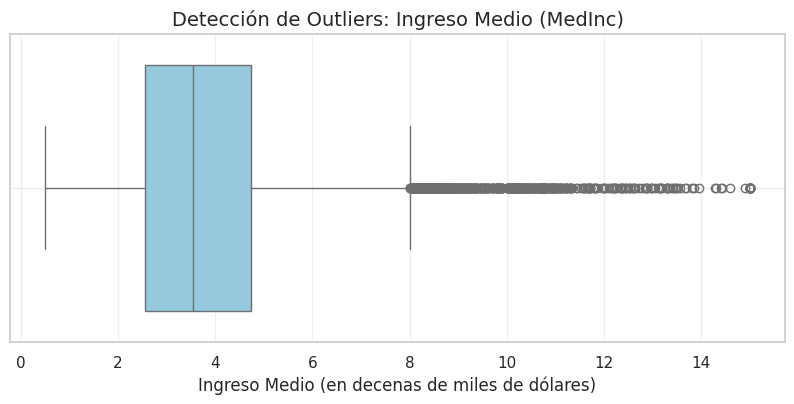

In [ ]:
plt.figure(figsize=(10, 4))

# Creamos un boxplot horizontal para el ingreso
sns.boxplot(x=df['MedInc'], color='skyblue')

plt.title('Detección de Outliers: Ingreso Medio (MedInc)', fontsize=14)
plt.xlabel('Ingreso Medio (en decenas de miles de dólares)')

# Añadimos una cuadrícula para facilitar la lectura
plt.grid(True, alpha=0.3)
plt.show()

**🔍 Análisis del Profesor:**

Fíjate cómo la "caja" (el grueso de la población) está concentrada entre los 2.5 y 4.5 (es decir, entre \$25,000 y \$45,000). Sin embargo, a la derecha de los bigotes, vemos un rastro de puntos que llegan hasta el 15 (\$150,000). Estos son distritos con ingresos atípicamente altos. Como son "valores reales" (es posible que existan barrios muy ricos), en un modelo de regresión podríamos decidir conservarlos o aplicarles una transformación logarítmica.

Pero... ¿qué pasa con aquellas variables que se veían aplastadas en los histogramas?

### 🧑‍💻 Ejercicio Práctico: Cazando Anomalías Extremas

Vamos a investigar la variable `AveRooms`, `AveBedrms`, `Population` .

**Tu tarea:**
1. Crea un boxplot horizontal para la columna `AveRooms`.
2. Observa la escala del eje X y los puntos individuales.
3. Responde a las preguntas en la celda de análisis inferior.

In [ ]:
plt.figure(figsize=(10, 4))

# 1. Crea aquí el boxplot para 'AveRooms'
# [TU CÓDIGO AQUÍ]




# 2. Añade un título descriptivo y la etiqueta del eje X
# [TU CÓDIGO AQUÍ]




plt.show()

**✍️ Tu Análisis (Responde aquí):**

Observando tu Boxplot de la variable `AveRooms`:

1. ¿Hasta qué valor llega el outlier más extremo en el eje X?
> *[Escribe tu respuesta aquí]*

2. Sabiendo que esta variable representa el "promedio de habitaciones por hogar en un distrito entero", ¿tiene sentido lógico ese valor extremo? ¿Qué crees que pudo haber pasado durante la recolección de los datos? (Pista: Piensa en hoteles o recintos que pudieron ser censados por error como "hogares").
> *[Escribe tu respuesta aquí]*

3. **Decisión de Data Science:** Si dejamos este distrito con >100 habitaciones promedio por casa en nuestro dataset, ¿cómo crees que afectará a nuestro algoritmo de predicción de precios?
> *[Escribe tu respuesta aquí]*

### Más allá del Histograma - Gráficos de Densidad (KDE)

Los histogramas son geniales, pero tienen un problema: su forma cambia drásticamente dependiendo de cuántas "barras" (`bins`) elijamos.

Para obtener una visión matemática más suave y real de la distribución de una variable numérica, usamos los **Gráficos de Densidad o KDE (Kernel Density Estimation)**. Piensa en ellos como un histograma continuo que no depende de las barras.

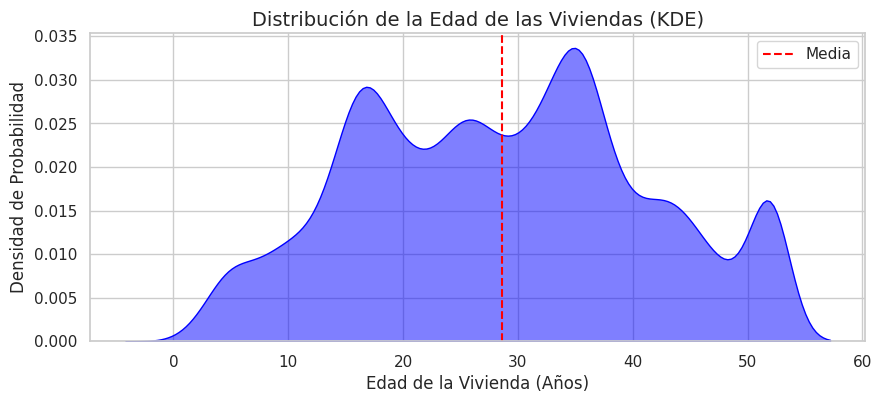

In [ ]:
plt.figure(figsize=(10, 4))

# Gráfico de densidad para la edad de las casas
sns.kdeplot(df['HouseAge'], fill=True, color='blue', alpha=0.5)

plt.title('Distribución de la Edad de las Viviendas (KDE)', fontsize=14)
plt.xlabel('Edad de la Vivienda (Años)')
plt.ylabel('Densidad de Probabilidad')

plt.axvline(df['HouseAge'].mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

### Análisis Univariado Categórico (Countplots)

Hasta ahora hemos analizado variables numéricas. Pero, ¿qué pasa con las variables categóricas (texto o etiquetas)? Para ellas, la herramienta reina es el **Gráfico de Barras de Frecuencia (Countplot)**.



**¡Pero tenemos un problema!** Si revisamos nuestro `df.info()`, el California Housing Dataset *no tiene variables categóricas*. Todo son números.

Como Científicos de Datos, a veces necesitamos crear nuestras propias categorías a partir de variables continuas para simplificar el análisis. A esto se le llama **Discretización (Binning)**.

In [5]:
# 1. Define los límites y las etiquetas
# Empezamos en 0, cortamos en 15 años (Nueva), luego en 35 años (Seminueva),
# y terminamos en 60 (un límite superior seguro ya que el máximo es 52).
limites = [0, 15, 35, 60]
etiquetas = ['Nueva', 'Seminueva', 'Antigua']

# 2. Crea la columna usando pd.cut
df['Age_Segment'] = pd.cut(df['HouseAge'], bins=limites, labels=etiquetas)

In [7]:
# 1. Obtenemos el conteo básico y lo convertimos en un DataFrame
tabla_age_segment = df.groupby('Age_Segment', observed=True).size().to_frame(name='Conteo')

# 2. Usamos .assign() para crear el Porcentaje y el Porcentaje Acumulado en un solo paso
tabla_age_segment = tabla_age_segment.assign(
    # Calculamos el porcentaje dividiendo el conteo entre el total de la columna
    Porcentaje = lambda x: (x['Conteo'] / x['Conteo'].sum()) * 100,

    # Calculamos el acumulado usando la función .cumsum() sobre la columna que acabamos de crear
    Porcentaje_Acumulado = lambda x: x['Porcentaje'].cumsum()
)

# Mostramos la tabla formateando los números para que se vean amigables
display(tabla_age_segment.round(2))

,Conteo,Porcentaje,Porcentaje_Acumulado
Age_Segment,,,
Nueva,3287,15.93,15.93
Seminueva,11009,53.34,69.26
Antigua,6344,30.74,100.00


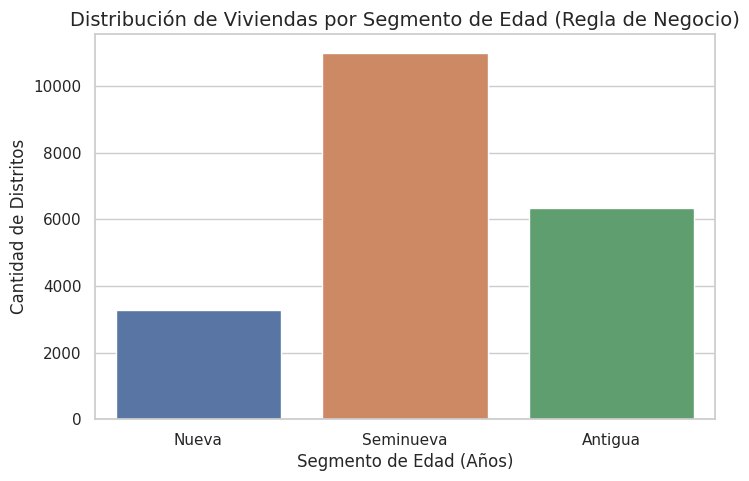

In [8]:
# Grafica el resultado con sns.countplot
plt.figure(figsize=(8, 5))

# Graficamos nuestra nueva variable dictada por el negocio
sns.countplot(data=df, x='Age_Segment', hue='Age_Segment')

plt.title('Distribución de Viviendas por Segmento de Edad (Regla de Negocio)', fontsize=14)
plt.xlabel('Segmento de Edad (Años)')
plt.ylabel('Cantidad de Distritos')
plt.show()

### 🧑‍💻 Ejercicio Práctico: Discretización de Precios con Reglas de Negocio

En el ejercicio anterior dividimos el valor de las viviendas (`MedHouseVal`) usando `pd.qcut`, lo que forzó a que los grupos de "Económica", "Media" y "Costosa" tuvieran exactamente la misma cantidad de casas.

Pero ahora, el equipo de ventas nos ha dado una **clasificación estricta basada en el valor en dólares**:
* **Económica:** Viviendas de \$0 a \$150,000 (0 a 1.5 en nuestra escala).
* **Media:** Viviendas de \$150,001 a \$300,000 (1.5 a 3.0).
* **Costosa:** Viviendas de más de \$300,000 (3.0 en adelante. Recuerda que nuestro máximo está topado en 5.0).

**Tu tarea:**
1. Utiliza `pd.cut()` para crear una nueva columna llamada `Business_Price_Category` usando los límites exactos de negocio.
2. Los límites (`bins`) serán: `[0, 1.5, 3.0, 5.5]`. *(Usamos 5.5 como límite superior para asegurarnos de incluir el tope de 5.0).*
3. Las etiquetas (`labels`) serán: `['Económica', 'Media', 'Costosa']`.
4. Genera una tabla de frecuencia
5. Genera un gráfico de barras de frecuencia (`countplot`) para visualizar esta nueva clasificación.

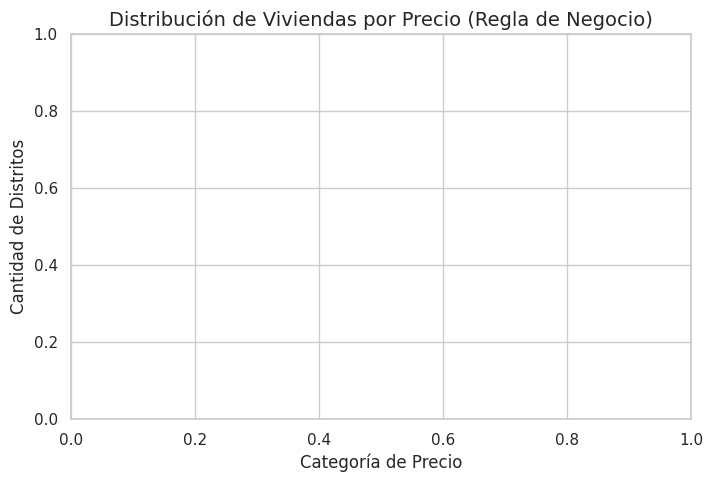

In [ ]:
# 1. Define los límites y las etiquetas dictadas por el negocio
limites_precio = [0, 1.5, 3.0, 5.5]
etiquetas_precio = ['Económica', 'Media', 'Costosa']

# 2. Crea la columna usando pd.cut sobre la variable 'MedHouseVal'
# Pista: df['Business_Price_Category'] = pd.cut(...)
# [TU CÓDIGO AQUÍ]




# 3. Genera el gráfico de barras usando sns.countplot
plt.figure(figsize=(8, 5))
# [TU CÓDIGO AQUÍ]




plt.title('Distribución de Viviendas por Precio (Regla de Negocio)', fontsize=14)
plt.xlabel('Categoría de Precio')
plt.ylabel('Cantidad de Distritos')
plt.show()

**✍️ Tu Análisis (Responde aquí):**


En esta nueva clasificación del negocio, ¿cuál es la categoría que predomina en el estado de California?
> *[Escribe tu respuesta aquí]*



---
## Ingeniería de Características (Feature Engineering)

Los datos crudos rara vez son la mejor opción para un modelo. Por ejemplo: ¿Qué nos dice más sobre la comodidad de una casa? ¿El número total de habitaciones en el distrito (`AveRooms`) o cuántas habitaciones hay disponibles **por cada persona** que vive allí?

Al crear ratios o proporciones, eliminamos el sesgo del tamaño de la población y creamos variables mucho más potentes. En esta sección aprenderemos a:
1. Usar `.apply()` con funciones `lambda` operando sobre múltiples columnas (`axis=1`).
2. Utilizar `.assign()` para mantener nuestro código limpio y encadenado.

In [ ]:
# Demostración: Creación de la variable "Habitaciones por Persona"
# Usamos .assign para mantener el estilo de "tubería" (pipeline) que aprendimos

df = df.assign(
    Rooms_per_Person = lambda x: x['AveRooms'] / x['AveOccup']
)

# Revisamos la nueva variable comparándola con sus componentes
display(df[['AveRooms', 'AveOccup', 'Rooms_per_Person']].head())

,AveRooms,AveOccup,Rooms_per_Person
0,6.984127,2.555556,2.732919
1,6.238137,2.109842,2.956685
2,8.288136,2.802260,2.957661
3,5.817352,2.547945,2.283154
4,6.281853,2.181467,2.879646


### 🧑‍💻 Ejercicio Práctico: Detectando el "Hacinamiento"

Un factor crítico en el valor de una propiedad es la relación entre dormitorios y el total de habitaciones. Si un distrito tiene un promedio de dormitorios muy alto respecto al total de cuartos, podría indicar viviendas con poco espacio común o alta densidad.

**Tu tarea:**
1. Crea una nueva columna llamada `Bedroom_Ratio` que sea el resultado de dividir `AveBedrms` entre `AveRooms`.
2. Utiliza el método `.apply()` con una función `lambda` que opere sobre las filas (`axis=1`).
   *💡 Nota: Aunque podrías hacerlo directamente como en el ejemplo anterior, practica el uso de `axis=1` ya que te permite meter lógica más compleja (como `if/else`) en el futuro.*
3. Muestra un resumen estadístico (`.describe()`) **solo** de esta nueva columna.

In [ ]:
# 1. Crea la variable Bedroom_Ratio usando apply y lambda
# Pista: df.apply(lambda row: row['ColumnaA'] / row['ColumnaB'], axis=1)
# [TU CÓDIGO AQUÍ]




# 2. Genera el resumen estadístico de la nueva columna
# [TU CÓDIGO AQUÍ]

**✍️ Tu Análisis (Responde aquí):**

Observa los resultados de `Bedroom_Ratio.describe()`:

1. ¿Cuál es el valor promedio (mean) de esta relación? ¿Es mayor o menor a 0.20 (es decir, 1 dormitorio por cada 5 habitaciones)?
> *[Escribe tu respuesta aquí]*

2. ¿Notas algún valor máximo extraño? Si el ratio es mayor a 1, significaría que hay más dormitorios que habitaciones totales (lo cual es físicamente imposible). ¿Qué nos diría esto sobre la calidad de nuestros datos?
> *[Escribe tu respuesta aquí]*

## Análisis Bivariado y Multivariado

En esta sección buscaremos la relación entre nuestras **características (features)** y nuestra **variable objetivo (`MedHouseVal`)**.

Existen tres formas principales de abordar esto visualmente:
1. **Numérica vs Numérica:** Usamos Diagramas de Dispersión (Scatter plots) para ver tendencias.
2. **Categórica vs Numérica:** Usamos Gráficos de Violín o Boxplots para ver cómo cambia el precio según el segmento (ej. ¿las casas antiguas son realmente más baratas?).
3. **Análisis Global:** Usamos Mapas de Calor (Heatmaps) para ver todas las correlaciones matemáticas de un solo vistazo.

### Relación Numérica vs. Numérica

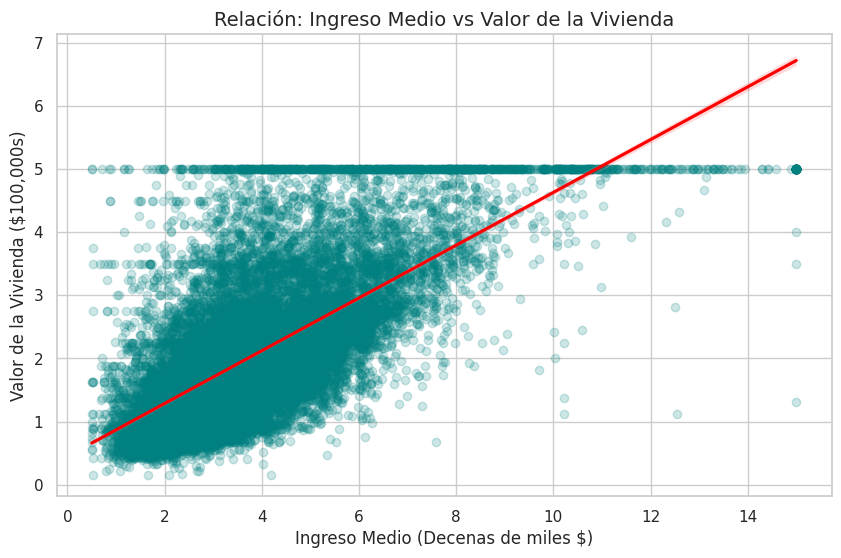

In [10]:
# Demostración: Ingreso Medio vs Valor de la Vivienda
plt.figure(figsize=(10, 6))

# regplot combina un scatter plot con una línea de regresión lineal
sns.regplot(data=df, x='MedInc', y='MedHouseVal',
            scatter_kws={'alpha':0.2, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Relación: Ingreso Medio vs Valor de la Vivienda', fontsize=14)
plt.xlabel('Ingreso Medio (Decenas de miles $)')
plt.ylabel('Valor de la Vivienda ($100,000s)')
plt.show()

**🔍 Análisis del Profesor:**

La línea roja confirma una **correlación positiva fuerte**: a medida que aumenta el ingreso en un distrito, el valor de las casas sube.
* **Nota técnica:** El coeficiente de correlación de Pearson ($r$) mide esta relación lineal. Si $r=1$ es una línea perfecta ascendente, y $r=-1$ es descendente. ¿Qué valor crees que tiene esta relación?

### El Mapa de Calor (Heatmap)

Finalmente, para no ir una por una, calculamos la **Matriz de Correlación de Pearson**. Este coeficiente varía entre $-1$ y $1$.



* $1$: Relación positiva perfecta.
* $0$: No hay relación lineal.
* $-1$: Relación negativa perfecta.

In [ ]:
# Matriz de correlación
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


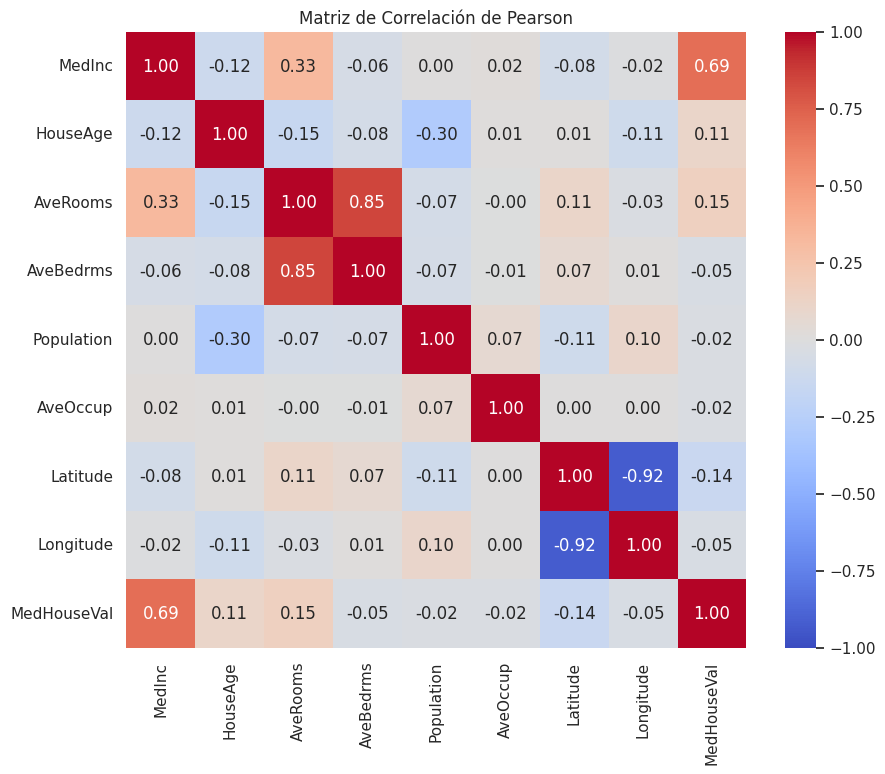

In [ ]:
# Visualización de la matriz de correlación
plt.figure(figsize=(10, 8))
# Seleccionamos solo variables numéricas

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson')
plt.show()

In [ ]:
# Visualiza las variables con mayor correlación (> 0.5 o < -0.5)
# [TU CÓDIGO AQUÍ]


### 🧑‍💻 Reto de Conclusión: Seleccionando tus predictores

Observa detenidamente el Mapa de Calor anterior, específicamente la última fila (o columna) correspondiente a `MedHouseVal`.

**Tu tarea (Responde aquí):**
1. ¿Cuál es la variable con la correlación más alta con el precio? (Ignorando el 1.0 de ella misma).
> *[Escribe aquí]*

2. Mira la variable que creamos: `Bedroom_Ratio`. ¿Tiene una correlación positiva o negativa con el precio? ¿Qué nos dice esto sobre el diseño de las casas y su valor?
> *[Escribe aquí]*

3. Si tuvieras que elegir solo **3 variables** para construir tu modelo de regresión la próxima clase, ¿cuáles elegirías basándote en este mapa?
> *[Escribe aquí]*

### Relación Numérica vs. Categórica

¿Realmente influye la edad de una casa en su precio? ¿O el segmento de ingresos en la cantidad de habitaciones? Para responder estas preguntas, comparamos una **variable numérica** (continua) contra una **variable categórica** (segmentos).

Las dos herramientas visuales más potentes para este análisis son:
1. **Boxplots Comparativos:** Permiten ver diferencias en la mediana y la dispersión (variabilidad) entre grupos.
2. **Gráficos de Densidad Condicional (KDE):** Permiten ver la "silueta" de la distribución de cada categoría superpuesta.

---
### 1. Comparación con Boxplots
Vamos a analizar cómo varía el valor de la vivienda (`MedHouseVal`) según el segmento de edad que creamos (`Age_Segment`).

/tmp/ipykernel_684/2084246073.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age_Segment', y='MedHouseVal', palette='Set2')


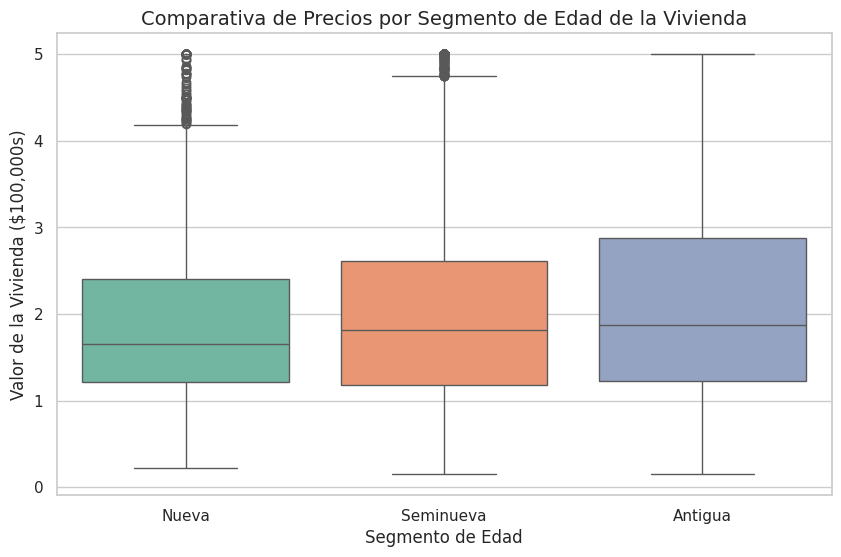

In [14]:
plt.figure(figsize=(10, 6))

# Creamos boxplots verticales para comparar las distribuciones de precio por segmento de edad
sns.boxplot(data=df, x='Age_Segment', y='MedHouseVal', palette='Set2')

plt.title('Comparativa de Precios por Segmento de Edad de la Vivienda', fontsize=14)
plt.xlabel('Segmento de Edad')
plt.ylabel('Valor de la Vivienda ($100,000s)')
plt.show()

### Comparación con Gráficos de Densidad (KDE)

A veces el Boxplot oculta detalles de la forma de la distribución. Al superponer gráficos de densidad (KDE) para cada categoría, podemos ver si los grupos tienen comportamientos bimodales o si sus curvas están muy desplazadas entre sí.

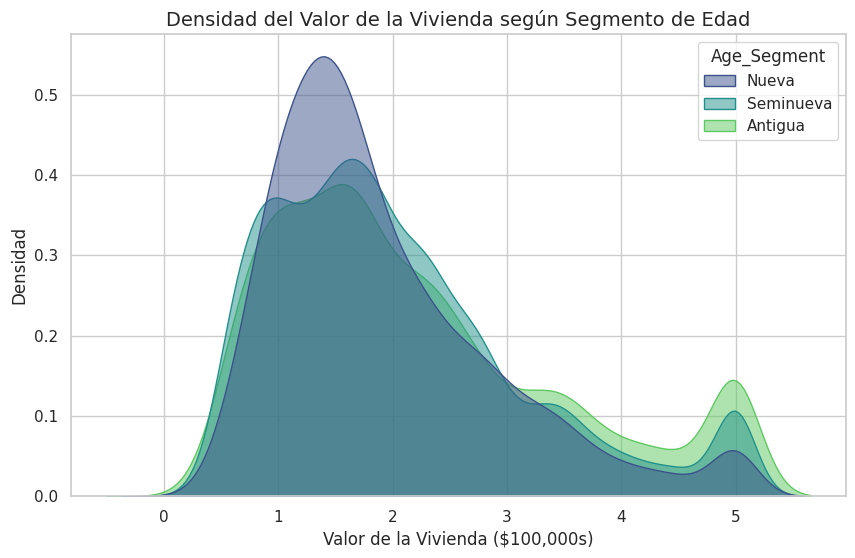

In [15]:
plt.figure(figsize=(10, 6))

# Graficamos la densidad del valor de la vivienda, separada por el segmento de edad (hue)
sns.kdeplot(data=df, x='MedHouseVal', hue='Age_Segment', fill=True, common_norm=False, palette='viridis', alpha=0.5)

plt.title('Densidad del Valor de la Vivienda según Segmento de Edad', fontsize=14)
plt.xlabel('Valor de la Vivienda ($100,000s)')
plt.ylabel('Densidad')
plt.show()

/tmp/ipykernel_684/3602332242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Age_Segment', y='MedHouseVal', palette='Set2')


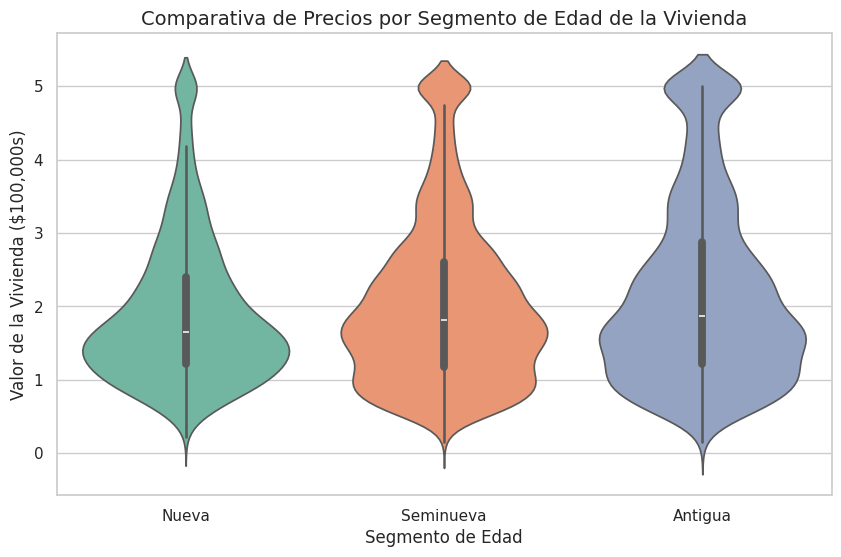

In [16]:
plt.figure(figsize=(10, 6))

# Creamos boxplots verticales para comparar las distribuciones de precio por segmento de edad
sns.violinplot(data=df, x='Age_Segment', y='MedHouseVal', palette='Set2')

plt.title('Comparativa de Precios por Segmento de Edad de la Vivienda', fontsize=14)
plt.xlabel('Segmento de Edad')
plt.ylabel('Valor de la Vivienda ($100,000s)')
plt.show()

### 🧑‍💻 Ejercicio Práctico: ¿El ingreso define el tamaño de la casa?

Ya vimos que el ingreso influye en el precio, pero... ¿influye también en el espacio? Vamos a analizar la relación entre los grupos de ingresos (`Income_Group`) y nuestra variable creada de ingeniería: `Rooms_per_Person`.

**Tu tarea:**
1. Crea un **Boxplot** comparando `Income_Group` (eje X) contra `Rooms_per_Person` (eje Y).
2. Para que el gráfico sea legible, limita el eje Y a un rango máximo de 5 (usa `plt.ylim(0, 5)`), ya que los outliers extremos pueden aplastar la caja.
3. Genera un breve análisis: ¿Tienen los grupos de ingresos altos más habitaciones por persona que los bajos?

**✍️ Tu Análisis (Responde aquí):**

1. Observando las medianas (la línea dentro de las cajas), ¿notas una tendencia ascendente a medida que sube el nivel de ingresos?
> *[Escribe tu respuesta aquí]*

2. Mira la dispersión (el tamaño de las cajas). ¿Cuál grupo de ingresos presenta mayor variabilidad en la cantidad de habitaciones por persona?
> *[Escribe tu respuesta aquí]*

## Relación Categórica vs. Categórica

Cuando ambas variables son cualitativas, el objetivo es observar cómo se distribuyen las categorías de una variable dentro de las categorías de otra.



Para esto utilizaremos:
1. **Tablas de Contingencia (`pd.crosstab`):** Una matriz que cuenta cuántos registros caen en cada combinación de categorías.
2. **Heatmaps de Frecuencia:** Para identificar visualmente "puntos calientes" de coincidencia.
3. **Gráficos de Barras Agrupados:** Para comparar proporciones visualmente.

---
### 1. Tablas de Contingencia (Crosstab)
Vamos a cruzar el **Segmento de Edad** (`Age_Segment`) con la **Categoría de Precio de Negocio** (`Business_Price_Category`).

In [19]:
# 1. Definimos los límites (bins) basados en las reglas de negocio
# 0-1.5 ($150k), 1.5-3.0 ($300k), 3.0-5.5 (Costosa)
limites_precio = [0, 1.5, 3.0, 5.5]

# 2. Definimos las etiquetas para cada intervalo
etiquetas_precio = ['Económica', 'Media', 'Costosa']

# 3. Creamos la nueva columna transformando la variable continua a categórica
df['Business_Price_Category'] = pd.cut(
    df['MedHouseVal'],
    bins=limites_precio,
    labels=etiquetas_precio,
    include_lowest=True  # Asegura que el valor 0 esté incluido en 'Económica'
)

In [21]:
# 1. Creamos la tabla de contingencia (conteo de frecuencias)
contingencia = pd.crosstab(df['Age_Segment'], df['Business_Price_Category'])

print("Tabla de Contingencia (Conteos Reales):")
display(contingencia)



Tabla de Contingencia (Conteos Reales):


Business_Price_Category,Económica,Media,Costosa
Age_Segment,,,
Nueva,1376,1451,460
Seminueva,4028,5090,1891
Antigua,2216,2643,1485


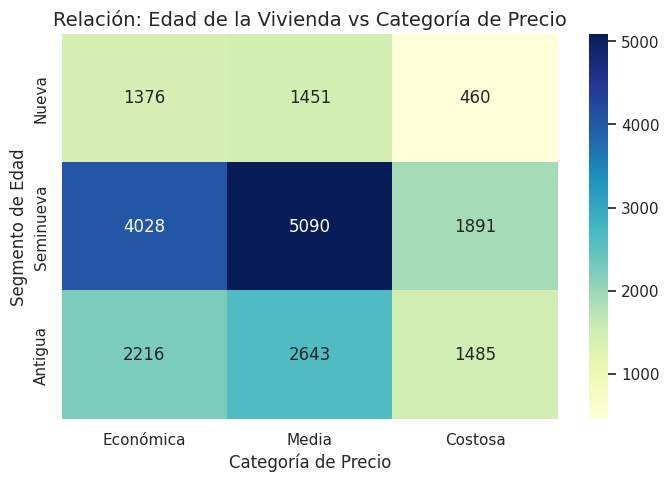

In [22]:
# 2. Visualización con un Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(contingencia, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Relación: Edad de la Vivienda vs Categoría de Precio', fontsize=14)
plt.ylabel('Segmento de Edad')
plt.xlabel('Categoría de Precio')
plt.show()

### Normalización de Tablas
A veces, los conteos totales nos engañan si un grupo es mucho más grande que otro. Para comparar de forma justa, es mejor usar **porcentajes (normalización)**.

Si usamos `normalize='index'`, cada fila sumará 100%, permitiéndonos ver, por ejemplo: *"De todas las casas antiguas, ¿qué porcentaje son costosas?"*.

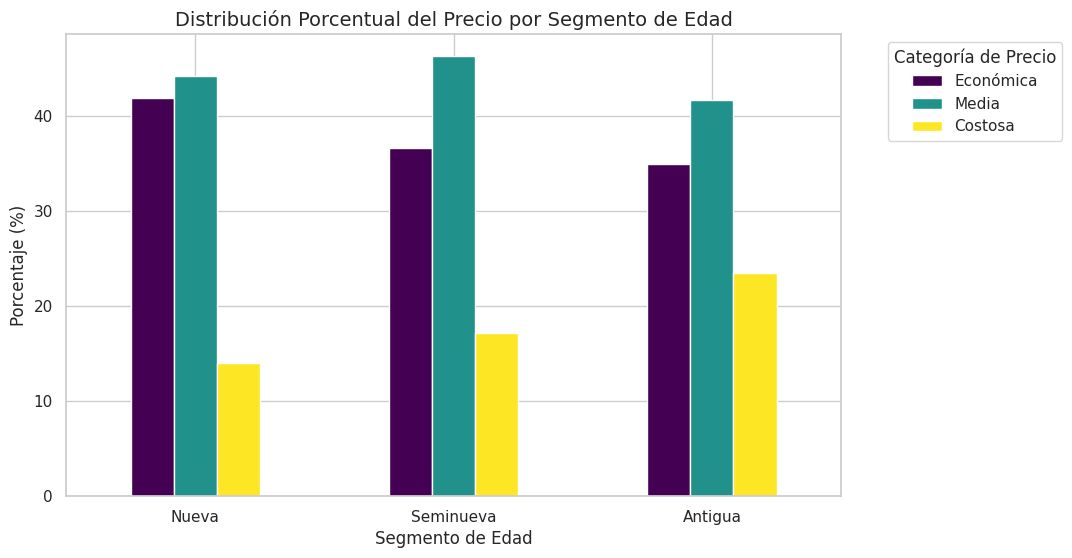

In [23]:
# Creamos la tabla normalizada por filas (índice)
contingencia_pct = pd.crosstab(df['Age_Segment'], df['Business_Price_Category'], normalize='index') * 100

# Graficamos barras agrupadas
contingencia_pct.plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Distribución Porcentual del Precio por Segmento de Edad', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Segmento de Edad')
plt.legend(title='Categoría de Precio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

### 🧑‍💻 Ejercicio Práctico: Ingresos vs. Precio de Negocio

Este es el cruce más importante para validar la lógica de nuestro dataset. Queremos ver si los grupos de ingresos que creamos coinciden con las categorías de precios de las casas.

**Tu tarea:**
1. Crea una **Tabla de Contingencia** usando `pd.crosstab` para cruzar `Income_Group` (filas) y `Business_Price_Category` (columnas).
2. Genera un gráfico de barras agrupado (`sns.countplot`) donde el eje X sea el `Income_Group` y las barras se separen por colores (`hue`) según la `Business_Price_Category`.
3. Responde: ¿Existe algún distrito de ingresos "Bajos" que tenga casas "Costosas"?

In [ ]:
# 1. Crea la tabla de contingencia aquí
# [TU CÓDIGO AQUÍ]


# 2. Genera el gráfico sns.countplot con el argumento hue
plt.figure(figsize=(12, 6))
# sns.countplot(data=df, x='Income_Group', hue='Business_Price_Category', palette='magma')
# [TU CÓDIGO AQUÍ]


plt.title('Relación entre Nivel de Ingresos y Categoría de Precio de la Vivienda')
plt.show()

**✍️ Tu Análisis (Responde aquí):**

1. Observando el gráfico, en el grupo de ingresos **"Alto"**, ¿cuál es la categoría de precio predominante? ¿Tiene sentido lógico?
> *[Escribe tu respuesta aquí]*

2. Mira el grupo de ingresos **"Bajo"**. ¿Es común encontrar viviendas de categoría "Costosa" en este grupo? ¿Qué nos dice esto sobre la capacidad predictiva de la variable ingreso?
> *[Escribe tu respuesta aquí]*

---
### El Contexto Geospacial

Finalmente, veamos el mapa de California usando las coordenadas. Esto nos demuestra que el factor espacial es vital (¡ubicación, ubicación, ubicación!). Luego, prepararemos el terreno para nuestro modelo de regresión calculando las correlaciones lineales.

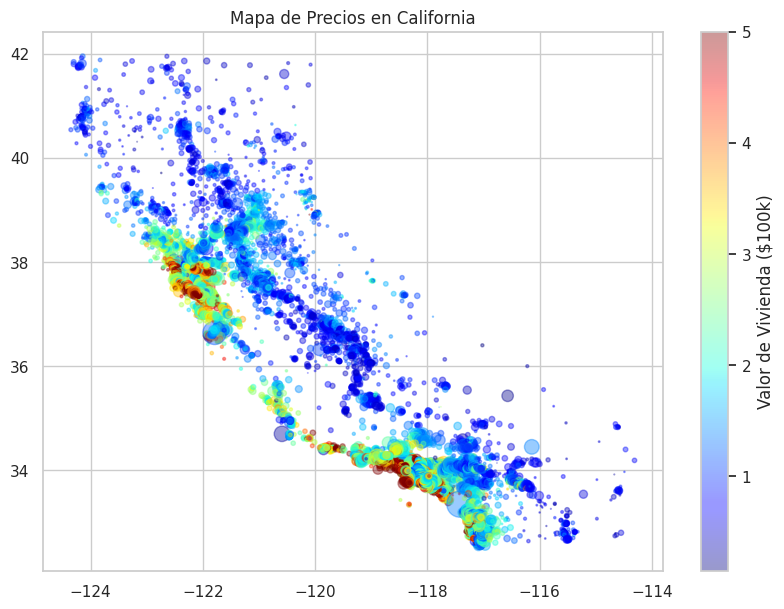

In [24]:
# 1. Mapa Geospacial
plt.figure(figsize=(10, 7))
plt.scatter(
    x=df['Longitude'], y=df['Latitude'],
    alpha=0.4, s=df['Population']/100,
    c=df['MedHouseVal'], cmap='jet'
)
plt.colorbar(label='Valor de Vivienda ($100k)')
plt.title('Mapa de Precios en California')
plt.show()

# 📈 Parte 2: Análisis de Series Temporales (Time Series)

En esta segunda mitad, trabajaremos con datos financieros. A diferencia del dataset de viviendas, aquí el **orden de las filas es crítico**. Exploraremos cómo las acciones de Apple (AAPL) han evolucionado en los últimos años.

**Nuevos conceptos de Pandas que aprenderemos:**
1. **DatetimeIndex:** Cómo convertir una columna de fechas en el motor de nuestro DataFrame.
2. **Resample:** Cambiar la frecuencia de los datos (de días a meses o años).
3. **Shift:** Desplazar datos en el tiempo para calcular rendimientos.
4. **Rolling Windows:** Suavizar curvas para identificar tendencias mediante medias móviles.

---
## 1. Configuración y Carga de Datos
Utilizaremos la librería `yfinance` para traer datos reales de la bolsa en tiempo real.

In [25]:
# Instalamos la librería necesaria si no está presente
!pip install yfinance -q

In [27]:
import yfinance as yf


# Descargamos 5 años de datos de Apple
df_apple = yf.download('AAPL', start='2019-01-01', end='2024-01-01')

# Inspección inicial
print("Estructura del DataFrame:")
df_apple.info()

df_apple.head()

/tmp/ipykernel_684/1763919694.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_apple = yf.download('AAPL', start='2019-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Estructura del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2019-01-04,35.209621,35.278494,34.150437,34.323801,234428400
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200
2019-01-08,35.800964,36.055076,35.271372,35.518356,164101200


## 2. El Poder del DatetimeIndex

En Pandas, cuando el índice es de tipo `datetime`, el DataFrame adquiere "superpoderes". Podemos filtrar por años, meses o rangos de fechas de forma casi literaria.



**Tu tarea:**
1. Filtra el DataFrame para mostrar únicamente los datos del año **2022**.
2. Filtra el DataFrame para mostrar el periodo entre **Marzo de 2023 y Junio de 2023**.

In [ ]:
# 1. Filtrar el año 2022
# Pista: df.loc['AAAA']
# [TU CÓDIGO AQUÍ]


# 2. Filtrar rango Marzo 2023 a Junio 2023
# Pista: df.loc['AAAA-MM':'AAAA-MM']
# [TU CÓDIGO AQUÍ]

## 3. Resampling: Cambiando la Frecuencia

¿Qué pasa si no queremos ver el precio día a día, sino el **precio promedio por mes**? Para esto usamos `.resample()`. Es como un `groupby` pero especializado en tiempo.

* **'W'**: Semanal (Weekly)
* **'M'**: Mensual (Monthly)
* **'Y'**: Anual (Yearly)

/tmp/ipykernel_859/3971999755.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  apple_mensual = df_apple['Close'].resample('M').mean()


<Figure size 1200x500 with 0 Axes>

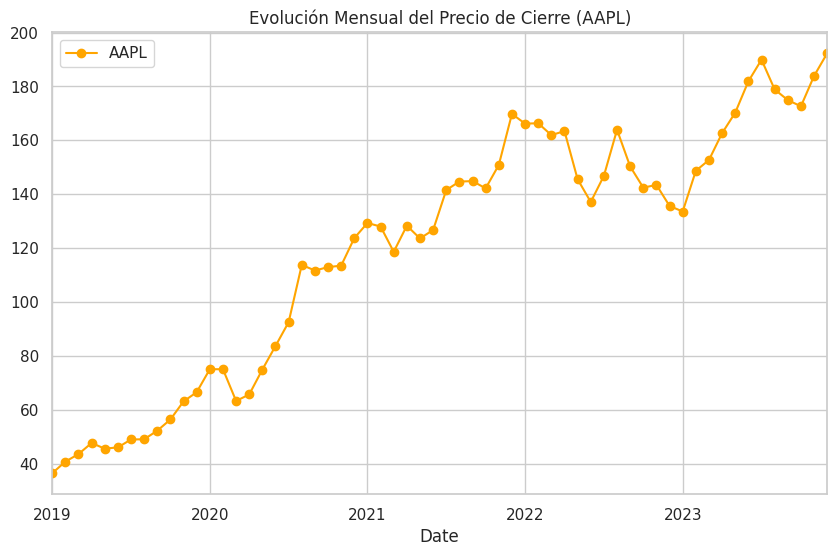

In [ ]:
# Demostración: Precio promedio de cierre por MES
apple_mensual = df_apple['Close'].resample('M').mean()

plt.figure(figsize=(12, 5))
apple_mensual.plot(label='Promedio Mensual', color='orange', marker='o')
plt.title('Evolución Mensual del Precio de Cierre (AAPL)')
plt.legend()
plt.show()

# --- RETO PARA EL ESTUDIANTE ---
# Calcula el volumen total de acciones negociadas (columna 'Volume') por AÑO.
# [TU CÓDIGO AQUÍ]